In [1]:
import sys
sys.path.insert(0, '/storage/agrp/barakma/PileupODD')

In [1]:
%load_ext autoreload
%autoreload 2

In [36]:
from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()


with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_particles/train-00000-of-00100.parquet", "rb") as f:
    particles = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_calo_hits/train-00000-of-00100.parquet", "rb") as f:
    calo_hits = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_tracks/train-00000-of-00100.parquet", "rb") as f:
    tracks = pl.read_parquet(f)


In [5]:
tracks

event_id,d0,z0,phi,theta,qop,majority_particle_id,hit_ids,track_id
u32,list[f32],list[f32],list[f32],list[f32],list[f32],list[u64],list[list[u32]],list[u16]
0,"[0.032012, -0.025235, … 0.035769]","[196.103989, 196.151077, … 196.153793]","[-2.826225, -2.705781, … 3.060707]","[2.153924, 0.443445, … 2.259682]","[-0.436399, 0.333322, … 0.77784]","[299, 88, … 301]","[[758, 434, … 148], [1576, 1574, … 145], … [1446, 1445, … 141]]","[0, 1, … 17]"
1,"[-0.007235, -0.053888, … -0.287625]","[106.114616, 106.039703, … 106.520576]","[-1.792339, -1.099716, … 2.426357]","[2.526565, 2.93867, … 2.018473]","[-0.025727, -0.122754, … -0.749054]","[323, 137, … 371]","[[1722, 1721, … 153], [654, 675, … 158], … [2283, 2281, … 214]]","[0, 1, … 31]"
2,"[0.001582, -0.00831, … 0.018245]","[49.427135, 49.386742, … 49.374954]","[-2.186104, -2.078311, … 3.074902]","[2.60952, 2.675211, … 1.27922]","[-0.257519, -0.086401, … 0.255563]","[377, 423, … 449]","[[1895, 699, … 193], [1593, 1362, … 198], … [2946, 2945, … 300]]","[0, 1, … 38]"
3,"[0.012293, -0.009539, … 0.055962]","[60.9883, 61.132366, … 61.085033]","[-2.939633, -2.722635, … 3.106705]","[0.366233, 0.651955, … 0.411703]","[0.185901, -0.282921, … 0.386388]","[344, 221, … 247]","[[3608, 3611, … 419], [3432, 3430, … 430], … [3563, 3564, … 418]]","[0, 1, … 52]"
4,"[-0.001918, -0.112189, … -0.111065]","[52.500202, 52.585842, … 50.392906]","[-2.783758, -2.467226, … 3.040744]","[2.589843, 2.362943, … 3.041416]","[-0.280142, -0.704174, … -0.093711]","[334, 133, … 523]","[[2372, 2373, … 334], [2876, 2875, … 151], … [897, 930, … 287]]","[0, 1, … 43]"
…,…,…,…,…,…,…,…,…
995,"[-0.005339, 0.178722, … 0.021674]","[-75.299545, -75.538338, … -75.318626]","[-3.095909, -2.66912, … 3.048441]","[1.875259, 1.497771, … 1.480694]","[0.231844, 0.097704, … -0.028542]","[713, 731, … 743]","[[3068, 3070, … 478], [4935, 4933, … 493], … [4811, 4809, … 566]]","[0, 1, … 91]"
996,"[0.027836, 0.109946, … 0.011276]","[-1.171952, -1.465703, … -1.178417]","[-3.010271, -3.048716, … 3.07567]","[2.426985, 2.931912, … 2.826628]","[0.48127, -0.094376, … 0.071278]","[767, 317, … 314]","[[4677, 4676, … 686], [1986, 2060, … 670], … [4138, 4141, … 677]]","[0, 1, … 74]"
997,"[-0.062553, 0.072479, … -0.027793]","[86.044167, 85.875015, … 86.255478]","[-3.041292, -3.085649, … 2.697324]","[2.81418, 2.473864, … 2.384273]","[0.140797, -0.715554, … 0.110962]","[647, 619, … 420]","[[3375, 3378, … 445], [3879, 3880, … 446], … [4387, 4385, … 438]]","[0, 1, … 80]"


In [76]:
from primary.preprocessing import preprocess_for_model
preprocessed = preprocess_for_model(particles=particles, tracks=tracks, calo_hits=calo_hits, num_of_events=10, pt_cut=0, eta_cut=5)

Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 8 iterations on 33593 depositors.
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 4 iterations.
Step 4: Final validation...
--- Starting Optimized 3D Clustering (MeanShift, bw=120.0) ---
Data prepared: 10 events. Time: 0.01s
Workload optimized: 10 events merged into 10 tasks.
Largest batch processing first (LPT scheduling).
Aggregating results...
Done. Total time: 9.13s
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 9 iterations.
Step 4: Final validation...


In [87]:
(df_particles.lazy()
 .select(['event_id', 'particle_id', 'pt', 'eta', 'has_track'])
 .explode(['pt', 'eta', 'has_track', 'particle_id'])
 .filter((pl.col('has_track')) & 
            ~((pl.col('pt') > 1.0) & 
            (pl.col('eta').abs() < 3.0))
         )    
).collect()

event_id,particle_id,pt,eta,has_track
u32,u64,f32,f32,bool
0,202,0.804238,0.079732,true
1,177,0.996494,-0.738364,true
1,308,0.715949,-0.485833,true
1,376,0.831635,-0.556416,true
2,82,0.847196,0.011653,true
…,…,…,…,…
9,747,0.821819,0.922742,true
9,918,0.975743,2.706317,true
9,1051,0.885153,-1.680138,true


In [77]:
df_deps=preprocessed['target_particles_deps']
df_particles=preprocessed['target_particles']
df_clusters=preprocessed['calo_clusters']
df_tracks=preprocessed['tracks']

In [78]:
df_tracks

event_id,d0,z0,phi,theta,qop,hit_ids,track_id,phi_int,eta_int,track_tanlambda,track_omega,eta,particle_idx
u32,list[f32],list[f32],list[f32],list[f32],list[f32],list[list[u32]],list[u16],list[f32],list[f32],list[f32],list[f32],list[f32],list[u32]
1,"[-0.007235, -0.053888, … -0.287625]","[106.114616, 106.039703, … 106.520576]","[-1.792339, -1.099716, … 2.426357]","[2.526565, 2.93867, … 2.018473]","[-0.025727, -0.122754, … -0.749054]","[[1722, 1721, … 153], [654, 675, … 158], … [2283, 2281, … 214]]","[0, 1, … 31]","[-1.748996, -0.745993, … -3.025416]","[-1.089033, -2.256074, … -0.386019]","[-1.415571, -4.860157, … -0.480193]","[-0.00004, -0.000548, … -0.000748]","[-1.147, -2.284638, … -0.463426]","[44, 3, … 56]"
2,"[0.001582, -0.00831, … 0.018245]","[49.427135, 49.386742, … 49.374954]","[-2.186104, -2.078311, … 3.074902]","[2.60952, 2.675211, … 1.27922]","[-0.257519, -0.086401, … 0.255563]","[[1895, 699, … 193], [1593, 1362, … 198], … [2946, 2945, … 300]]","[0, 1, … 38]","[-1.687563, -1.89127, … 2.814815]","[-1.285817, -1.418113, … 0.340101]","[-1.698644, -1.986405, … 0.30013]","[-0.000457, -0.000173, … 0.00024]","[-1.300133, -1.437539, … 0.295798]","[55, 67, … 83]"
5,"[-0.003103, -0.008347, … -0.015018]","[-38.151382, -38.37936, … -38.262405]","[-2.975606, -2.86293, … 2.873475]","[2.771352, 0.488045, … 0.741196]","[0.172809, -0.262056, … 0.115564]","[[4671, 4670, … 424], [5665, 5666, … 438], … [5208, 5215, … 410]]","[0, 1, … 63]","[2.839095, -2.312793, … 2.706912]","[-1.696386, 1.384927, … 0.922067]","[-2.57639, 1.883668, … 1.092557]","[0.00043, -0.000503, … 0.000154]","[-1.675234, 1.390366, … 0.945331]","[4, 132, … 89]"
3,"[0.012293, -0.009539, … 0.055962]","[60.9883, 61.132366, … 61.085033]","[-2.939633, -2.722635, … 3.106705]","[0.366233, 0.651955, … 0.411703]","[0.185901, -0.282921, … 0.386388]","[[3608, 3611, … 419], [3432, 3430, … 430], … [3563, 3564, … 418]]","[0, 1, … 52]","[2.833445, -2.265424, … 2.129795]","[1.716367, 1.125244, … 1.624849]","[2.607322, 1.310112, … 2.290128]","[0.000467, -0.00042, … 0.000869]","[1.686369, 1.084602, … 1.566335]","[44, 17, … 24]"
4,"[-0.001918, -0.112189, … -0.111065]","[52.500202, 52.585842, … 50.392906]","[-2.783758, -2.467226, … 3.040744]","[2.589843, 2.362943, … 3.041416]","[-0.280142, -0.704174, … -0.093711]","[[2372, 2373, … 334], [2876, 2875, … 151], … [897, 930, … 287]]","[0, 1, … 43]","[-2.258257, -1.449274, … -2.981332]","[-1.246272, -0.888442, … -2.979553]","[-1.624655, -1.013588, … -9.948992]","[-0.000481, -0.000902, … -0.000843]","[-1.261979, -0.890949, … -2.993135]","[46, 6, … 76]"
9,"[0.183928, 0.06389, … -0.021738]","[41.758404, 41.337082, … 40.993637]","[-2.965677, -2.924305, … 2.981759]","[2.95949, 3.026598, … 2.67031]","[-0.154488, -0.040874, … -0.638143]","[[1818, 1904, … 673], [1719, 1847, … 653], … [4191, 4190, … 648]]","[0, 1, … 68]","[-2.5314, -2.81057, … -1.797488]","[-2.387845, -2.841994, … -1.497053]","[-5.430582, -8.657725, … -1.962398]","[-0.000768, -0.000321, … -0.001265]","[-2.393565, -2.854918, … -1.426692]","[84, 23, … 11]"
8,"[-0.002975, 0.022392, … 0.007247]","[74.43399, 74.450241, … 74.449463]","[-3.081555, -3.021165, … 2.648089]","[1.254286, 1.011232, … 2.525038]","[0.553201, -0.22177, … 0.030548]","[[2756, 2755, … 368], [2761, 2760, … 370], … [2417, 2412, … 363]]","[0, 1, … 44]","[2.62798, -2.766122, … 2.596732]","[0.390941, 0.65019, … -1.10393]","[0.327521, 0.626343, … -1.410995]","[0.000524, -0.000236, … 0.000048]","[0.321931, 0.591283, … -1.144356]","[3, 2, … 20]"
7,"[-0.131737, -0.018506, … -0.039972]","[-9.222378, -8.912401, … -8.842798]","[-3.061492, -2.962467, … 2.5804]","[3.033864, 3.035057, … 2.829936]","[-0.131412, 0.004419, … 0.252722]","[[1246, 1370, … 639], [48, 119, … 641], … [2933, 2934, … 616]]","[0, 1, … 53]","[-2.70214, -2.974552, … 1.858461]","[-2.928703, -2.934412, … -1.874431]","[-9.246626, -9.350996, … -3.104098]","[-0.0011, 0.000037, … 0.000742]","[-2.920317, -2.931477, … -1.850861]","[43, 107, … 8]"
6,"[-0.139306, 0.030785, … 

In [70]:
tracks

event_id,d0,z0,phi,theta,qop,majority_particle_id,hit_ids,track_id
u32,list[f32],list[f32],list[f32],list[f32],list[f32],list[u64],list[list[u32]],list[u16]
0,"[0.032012, -0.025235, … 0.035769]","[196.103989, 196.151077, … 196.153793]","[-2.826225, -2.705781, … 3.060707]","[2.153924, 0.443445, … 2.259682]","[-0.436399, 0.333322, … 0.77784]","[299, 88, … 301]","[[758, 434, … 148], [1576, 1574, … 145], … [1446, 1445, … 141]]","[0, 1, … 17]"
1,"[-0.007235, -0.053888, … -0.287625]","[106.114616, 106.039703, … 106.520576]","[-1.792339, -1.099716, … 2.426357]","[2.526565, 2.93867, … 2.018473]","[-0.025727, -0.122754, … -0.749054]","[323, 137, … 371]","[[1722, 1721, … 153], [654, 675, … 158], … [2283, 2281, … 214]]","[0, 1, … 31]"
2,"[0.001582, -0.00831, … 0.018245]","[49.427135, 49.386742, … 49.374954]","[-2.186104, -2.078311, … 3.074902]","[2.60952, 2.675211, … 1.27922]","[-0.257519, -0.086401, … 0.255563]","[377, 423, … 449]","[[1895, 699, … 193], [1593, 1362, … 198], … [2946, 2945, … 300]]","[0, 1, … 38]"
3,"[0.012293, -0.009539, … 0.055962]","[60.9883, 61.132366, … 61.085033]","[-2.939633, -2.722635, … 3.106705]","[0.366233, 0.651955, … 0.411703]","[0.185901, -0.282921, … 0.386388]","[344, 221, … 247]","[[3608, 3611, … 419], [3432, 3430, … 430], … [3563, 3564, … 418]]","[0, 1, … 52]"
4,"[-0.001918, -0.112189, … -0.111065]","[52.500202, 52.585842, … 50.392906]","[-2.783758, -2.467226, … 3.040744]","[2.589843, 2.362943, … 3.041416]","[-0.280142, -0.704174, … -0.093711]","[334, 133, … 523]","[[2372, 2373, … 334], [2876, 2875, … 151], … [897, 930, … 287]]","[0, 1, … 43]"
…,…,…,…,…,…,…,…,…
995,"[-0.005339, 0.178722, … 0.021674]","[-75.299545, -75.538338, … -75.318626]","[-3.095909, -2.66912, … 3.048441]","[1.875259, 1.497771, … 1.480694]","[0.231844, 0.097704, … -0.028542]","[713, 731, … 743]","[[3068, 3070, … 478], [4935, 4933, … 493], … [4811, 4809, … 566]]","[0, 1, … 91]"
996,"[0.027836, 0.109946, … 0.011276]","[-1.171952, -1.465703, … -1.178417]","[-3.010271, -3.048716, … 3.07567]","[2.426985, 2.931912, … 2.826628]","[0.48127, -0.094376, … 0.071278]","[767, 317, … 314]","[[4677, 4676, … 686], [1986, 2060, … 670], … [4138, 4141, … 677]]","[0, 1, … 74]"
997,"[-0.062553, 0.072479, … -0.027793]","[86.044167, 85.875015, … 86.255478]","[-3.041292, -3.085649, … 2.697324]","[2.81418, 2.473864, … 2.384273]","[0.140797, -0.715554, … 0.110962]","[647, 619, … 420]","[[3375, 3378, … 445], [3879, 3880, … 446], … [4387, 4385, … 438]]","[0, 1, … 80]"


In [43]:
n_tracks = df_tracks.select(pl.col("track_id").list.len()).to_series().to_numpy()
n_clusters = df_clusters.select(pl.col("cluster_id").list.len()).to_series().to_numpy()
n_particles = df_particles.select(pl.col("particle_id").list.len()).to_series().to_numpy()
n_deps = df_deps.select(pl.col("particle_idx").list.len()).to_series().to_numpy()

In [48]:
n_clusters

array([331, 415, 594, 714, 485, 867, 961, 845, 586, 920], dtype=uint32)

In [46]:
# 3. Filter Events
# ---------------------------------------------------------------------
n_nodes = n_tracks + n_clusters
mask = (n_nodes < 3000) & (n_particles < 300)

print(f"Total events: {len(mask)}")
print(f"Removing {(~mask).sum()} events with too many nodes or particles")

Total events: 10
Removing 0 events with too many nodes or particles


In [35]:
df_tracks

event_id,d0,z0,phi,theta,qop,majority_particle_id,hit_ids,track_id,phi_int,eta_int,track_tanlambda,track_omega,phi_int_right,eta_int_right,track_tanlambda_right,track_omega_right
u32,list[f32],list[f32],list[f32],list[f32],list[f32],list[u64],list[list[u32]],list[u16],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32]
0,"[0.032012, -0.025235, … 0.035769]","[196.103989, 196.151077, … 196.153793]","[-2.826225, -2.705781, … 3.060707]","[2.153924, 0.443445, … 2.259682]","[-0.436399, 0.333322, … 0.77784]","[299, 88, … 301]","[[758, 434, … 148], [1576, 1574, … 145], … [1446, 1445, … 141]]","[0, 1, … 17]","[-2.312437, 2.803079, … 2.037204]","[-0.468099, 1.586282, … -0.635306]","[-0.659648, 2.10528, … -0.823465]","[-0.000471, 0.000699, … 0.000907]","[-2.312437, 2.803079, … 2.037204]","[-0.468099, 1.586282, … -0.635306]","[-0.659648, 2.10528, … -0.823465]","[-0.000471, 0.000699, … 0.000907]"
1,"[-0.007235, -0.053888, … -0.287625]","[106.114616, 106.039703, … 106.520576]","[-1.792339, -1.099716, … 2.426357]","[2.526565, 2.93867, … 2.018473]","[-0.025727, -0.122754, … -0.749054]","[323, 137, … 371]","[[1722, 1721, … 153], [654, 675, … 158], … [2283, 2281, … 214]]","[0, 1, … 31]","[-1.748996, -0.745993, … -3.025416]","[-1.089033, -2.256074, … -0.386019]","[-1.415571, -4.860157, … -0.480193]","[-0.00004, -0.000548, … -0.000748]","[-1.748996, -0.745993, … -3.025416]","[-1.089033, -2.256074, … -0.386019]","[-1.415571, -4.860157, … -0.480193]","[-0.00004, -0.000548, … -0.000748]"
2,"[0.001582, -0.00831, … 0.018245]","[49.427135, 49.386742, … 49.374954]","[-2.186104, -2.078311, … 3.074902]","[2.60952, 2.675211, … 1.27922]","[-0.257519, -0.086401, … 0.255563]","[377, 423, … 449]","[[1895, 699, … 193], [1593, 1362, … 198], … [2946, 2945, … 300]]","[0, 1, … 38]","[-1.687563, -1.89127, … 2.814815]","[-1.285817, -1.418113, … 0.340101]","[-1.698644, -1.986405, … 0.30013]","[-0.000457, -0.000173, … 0.00024]","[-1.687563, -1.89127, … 2.814815]","[-1.285817, -1.418113, … 0.340101]","[-1.698644, -1.986405, … 0.30013]","[-0.000457, -0.000173, … 0.00024]"
3,"[0.012293, -0.009539, … 0.055962]","[60.9883, 61.132366, … 61.085033]","[-2.939633, -2.722635, … 3.106705]","[0.366233, 0.651955, … 0.411703]","[0.185901, -0.282921, … 0.386388]","[344, 221, … 247]","[[3608, 3611, … 419], [3432, 3430, … 430], … [3563, 3564, … 418]]","[0, 1, … 52]","[2.833445, -2.265424, … 2.129795]","[1.716367, 1.125244, … 1.624849]","[2.607322, 1.310112, … 2.290128]","[0.000467, -0.00042, … 0.000869]","[2.833445, -2.265424, … 2.129795]","[1.716367, 1.125244, … 1.624849]","[2.607322, 1.310112, … 2.290128]","[0.000467, -0.00042, … 0.000869]"
4,"[-0.001918, -0.112189, … -0.111065]","[52.500202, 52.585842, … 50.392906]","[-2.783758, -2.467226, … 3.040744]","[2.589843, 2.362943, … 3.041416]","[-0.280142, -0.704174, … -0.093711]","[334, 133, … 523]","[[2372, 2373, … 334], [2876, 2875, … 151], … [897, 930, … 287]]","[0, 1, … 43]","[-2.258257, -1.449274, … -2.981332]","[-1.246272, -0.888442, … -2.979553]","[-1.624655, -1.013588, … -9.948992]","[-0.000481, -0.000902, … -0.000843]","[-2.258257, -1.449274, … -2.981332]","[-1.246272, -0.888442, … -2.979553]","[-1.624655, -1.013588, … -9.948992]","[-0.000481, -0.000902, … -0.000843]"
5,"[-0.003103, -0.008347, … -0.015018]","[-38.151382, -38.37936, … -38.262405]","[-2.975606, -2.86293, … 2.873475]","[2.771352, 0.488045, … 0.741196]","[0.172809, -0.262056, … 0.115564]","[184, 953, … 847]","[[4671, 4670, … 424], [5665, 5666, … 438], … [5208, 5215, … 410]]","[0, 1, … 63]","[2.839095, -2.312793, … 2.706912]","[-1.696386, 1.384927, … 0.922067]","[-2.57639, 1.883668, … 1.092557]","[0.00043, -0.000503, … 0.000154]","[2.839095, -2.312793, … 2.706912]","[-1.696386, 1.384927, … 0.922067]","[-2.57639, 1.883668, … 1.092557]","[0.00043, -0.000503, … 0.000154]"
6,"[-0.139306, 0.030785, … 0.058325]","[-2.267007, -1.712351, … -1.685506]","[-3.014295, -2.940904, … 3.031545]","[2.892523, 2.801454, … 2.638982]","[0.20807, 0.430545, … -0.

In [5]:
target_particles = preprocessed['target_particles']
truth_particles = preprocessed['truth_particles']
calo_clusters = preprocessed['calo_clusters']
tracks = preprocessed['tracks']

In [50]:
calo_clusters

event_id,cluster_id,total_cluster_energy,cluster_cx,cluster_cy,cluster_cz
u32,list[i32],list[f64],list[f32],list[f32],list[f32]
0,"[0, 1, … 330]","[117.038543, 13.86953, … 0.012899]","[82.099648, 862.302429, … -2929.909912]","[-1263.230957, 1032.093506, … -694.060181]","[3305.375977, -290.279144, … 5432.5]"
1,"[0, 1, … 414]","[127.071303, 65.037671, … 0.034808]","[-279.106384, 453.047211, … -2355.019043]","[-1303.080688, -777.688049, … 1633.770264]","[-1781.132812, -3294.084961, … 30.0]"
2,"[0, 1, … 593]","[59.975367, 47.772519, … 0.033052]","[-1330.139282, -608.895935, … -1989.682617]","[112.237022, -1213.421143, … 434.49231]","[330.038788, -2807.855225, … 870.0]"
3,"[0, 1, … 713]","[48.13458, 45.11502, … 0.015514]","[-784.961243, 1231.401367, … -2376.398193]","[1118.737671, -535.188843, … -854.449219]","[426.975983, -327.448303, … 3698.5]"
4,"[0, 1, … 484]","[46.673636, 14.84895, … 0.024687]","[1125.668335, 707.334534, … -1874.877563]","[-730.552307, 1171.266846, … 711.656189]","[1113.420532, 806.041016, … 690.0]"
5,"[0, 1, … 866]","[56.867899, 31.121075, … 0.028071]","[-165.041275, -1268.863892, … -2155.192871]","[358.53891, 347.2724, … 567.992493]","[3326.897949, 1293.914673, … -3240.0]"
6,"[0, 1, … 961]","[83.598469, 70.526036, … 0.119777]","[-244.706863, -268.75415, … -1661.053467]","[-239.107132, -671.726868, … 428.256714]","[-3333.455078, -3305.769287, … 2040.0]"
7,"[0, 1, … 844]","[273.347295, 181.332376, … 0.01218]","[-352.664215, 55.095375, … -2325.486816]","[-77.463295, -1249.410645, … -1223.022339]","[-3335.097656, 3325.908447, … 3450.0]"
8,"[0, 1, … 585]","[346.705919, 122.993727, … 0.038514]","[-388.283386, 839.877502, … -1915.905884]","[1274.554565, -1190.164673, … -2000.758667]","[-1374.43042, -4.05305, … -1680.0]"


In [51]:
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import add_eta_and_phi_and_pt
from primary.preprocessing import set_target_particles_maskv2
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3, add_ms_cluster_labels
calo = calo_hits.filter(pl.col('event_id')< 100)
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_eta_and_phi_and_pt(particles)
particles = get_particles_id_parent_of_inside_calo_particles_maskv3(particles, calo)
particles = set_target_particles_maskv2(particles)
# apply cu

calo = add_ms_cluster_labels(calo, bandwidth=120.0)

Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 433815 depositors.
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 3 iterations.
Step 4: Final validation...
--- Starting Optimized 3D Clustering (MeanShift, bw=120.0) ---
Data prepared: 100 events. Time: 0.07s
Workload optimized: 100 events merged into 100 tasks.
Largest batch processing first (LPT scheduling).
Aggregating results...
Done. Total time: 29.56s


In [63]:
cells_clust =(calo.select(['event_id', 'cluster_id', 'detector'])
.explode(['cluster_id', 'detector'])
.group_by(['event_id', 'detector', 'cluster_id'])
.agg([pl.count().alias('n_cells')])
.sort(['event_id', 'detector', 'cluster_id'])
.join(
    ((calo.select(['event_id', 'cluster_id', 'detector'])
.explode(['cluster_id', 'detector'])
.group_by(['event_id', 'detector', 'cluster_id'])
.agg([pl.count().alias('n_cells')])
.group_by(['event_id', 'cluster_id'])
.agg([pl.count().alias('n_detectors')])
.sort(['n_detectors'], descending=True)
.filter(pl.col('n_detectors')>1)
)),
on=['event_id', 'cluster_id'],
how='inner'
)
)


/tmp/ipykernel_885261/1940663240.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias('n_cells')])
/tmp/ipykernel_885261/1940663240.py:10: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias('n_cells')])
/tmp/ipykernel_885261/1940663240.py:12: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias('n_detectors')])


In [65]:
cells_clust['n_cells'].sum()

24659

In [68]:
calo.select('x').explode('x')

x
f32
-319.95813
-180.72757
-251.553864
-172.447266
574.516541
…
1054.826538
1116.081299
-165.032837


/tmp/ipykernel_885261/1102950304.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias('n_cells')])
/tmp/ipykernel_885261/1102950304.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias('n_detectors')])


event_id,cluster_id,n_detectors
u32,i32,u32
24,421,2
67,96,2
90,108,2
10,675,2
27,299,2
…,…,…
76,726,2
46,395,2
24,241,2


In [49]:
# write preprocessed data to local disk as parquets
file_path = "/storage/agrp/barakma/PileupODD/data"
for key, df in preprocessed.items():
    df.write_parquet(f"{file_path}/{key}.parquet")

In [10]:
# try to see if i can load one of them
cl=pl.read_parquet(f"{file_path}/preprocessed_calo_clusters.parquet")
cl

event_id,cluster_id,total_cluster_energy,cluster_cx,cluster_cy,cluster_cz
u32,list[i32],list[f64],list[f32],list[f32],list[f32]
0,"[0, 1, … 330]","[117.038543, 13.86953, … 0.012899]","[82.099648, 862.302429, … -2929.909912]","[-1263.230957, 1032.093506, … -694.060181]","[3305.375977, -290.279144, … 5432.5]"
1,"[0, 1, … 414]","[127.071303, 65.037671, … 0.034808]","[-279.106384, 453.047211, … -2355.019043]","[-1303.080688, -777.688049, … 1633.770264]","[-1781.132812, -3294.084961, … 30.0]"
2,"[0, 1, … 593]","[59.975367, 47.772519, … 0.033052]","[-1330.139282, -608.895935, … -1989.682617]","[112.237022, -1213.421143, … 434.49231]","[330.038788, -2807.855225, … 870.0]"
3,"[0, 1, … 713]","[48.13458, 45.11502, … 0.015514]","[-784.961243, 1231.401367, … -2376.398193]","[1118.737671, -535.188843, … -854.449219]","[426.975983, -327.448303, … 3698.5]"
4,"[0, 1, … 484]","[46.673636, 14.84895, … 0.024687]","[1125.668335, 707.334534, … -1874.877563]","[-730.552307, 1171.266846, … 711.656189]","[1113.420532, 806.041016, … 690.0]"
…,…,…,…,…,…
95,"[0, 1, … 617]","[66.242444, 72.488217, … 0.78129]","[-334.895905, 321.225037, … -2202.310791]","[-215.548737, -1292.880737, … -587.509338]","[-3305.510254, 1501.251709, … 1620.0]"
96,"[0, 1, … 840]","[115.692938, 75.688911, … 0.034788]","[-846.895569, 784.731628, … -2475.934326]","[-1037.897461, 1089.703979, … -2306.22876]","[643.532349, -762.927063, … 1740.0]"
97,"[0, 1, … 991]","[1230.503656, 494.178099, … 0.052503]","[-401.495972, 688.888123, … -2412.5]","[40.472782, -416.98941, … -60.0]","[-3335.438477, -3323.664062, … 630.0]"


In [ ]:
tr

'/storage/agrp/barakma/PileupODD'

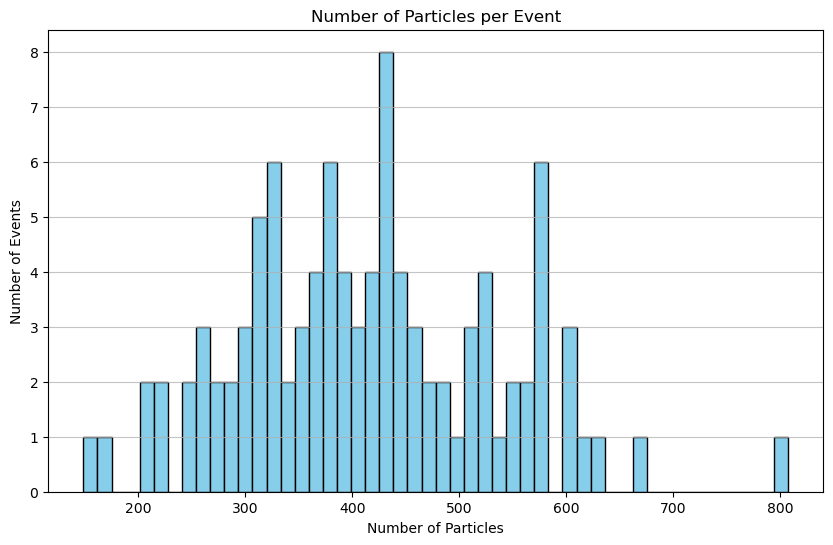

In [9]:
import matplotlib.pyplot as plt

# Calculate number of particles per event from target_particles
# particle_id is a list[u64], so we take the length of the list for each event
n_particles = target_particles["particle_id"].list.len()

plt.figure(figsize=(10, 6))
plt.hist(n_particles, bins=50, color='skyblue', edgecolor='black')
plt.title('Number of Particles per Event')
plt.xlabel('Number of Particles')
plt.ylabel('Number of Events')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# Explode the energy list to get individual particle energies
particle_energies = target_particles["energy"].explode()

plt.figure(figsize=(10, 6))
plt.hist(particle_energies, bins=100, color='salmon', edgecolor='black')
plt.title('Target Particle Energy Distribution')
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of Particles')
plt.yscale('log') # Using log scale as energy distributions often span orders of magnitude
plt.grid(axis='y', alpha=0.75)
plt.show()